INITIALIZATION

In [1]:
import numpy as np
import cv2
import os
from matplotlib import pyplot as plt
import sys
from scipy.ndimage import label, uniform_filter, binary_dilation, convolve, distance_transform_edt
from PIL import Image
np.set_printoptions(threshold=sys.maxsize)
from scipy.interpolate import splprep, splev
from io import StringIO
import struct
import heapq
from collections import Counter
import itertools
import io
from skimage.metrics import structural_similarity as ssim

In [2]:
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder,filename))
        if img is not None:
            images.append(img)
    return images
pics = np.zeros(shape=(7, 256, 256, 3))
pics = load_images_from_folder('BSDS500/train')

COMPRESSION

In [3]:
#Image-level complexity from local LAB standard deviation.
def local_lab_complexity_score(img_bgr, window_size=7, statistic="median"):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float64)

    # OpenCV LAB - standard-like LAB
    L = lab[:, :, 0] * (100.0 / 255.0)
    A = lab[:, :, 1] - 128.0
    B = lab[:, :, 2] - 128.0

    std_maps = []
    for ch in (L, A, B):
        mu = uniform_filter(ch, size=window_size, mode="reflect")
        mu2 = uniform_filter(ch * ch, size=window_size, mode="reflect")
        var = np.maximum(mu2 - mu * mu, 0.0)
        std_maps.append(np.sqrt(var))

    local_std = np.sqrt(std_maps[0]**2 + std_maps[1]**2 + std_maps[2]**2)

    if statistic == "mean":
        score = float(np.mean(local_std))
    else:
        score = float(np.median(local_std))

    return score, local_std

def adaptive_deltaE_threshold(complexity_score, low_complexity=2.0, high_complexity=12.0, high_thresh=10.0, low_thresh=4.0):
    # Low complexity - higher threshold
    # High complexity - lower threshold
    
    t = (complexity_score - low_complexity) / (high_complexity - low_complexity)
    t = np.clip(t, 0.0, 1.0)
    thresh = high_thresh * (1.0 - t) + low_thresh * t
    return float(thresh)

Adaptive complexity score: 2.026
Adaptive thresh (deltaE-like): 7.990


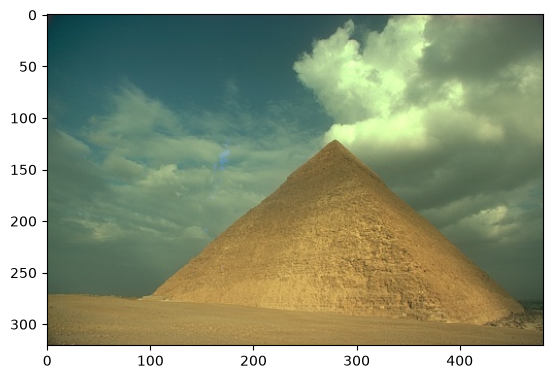

In [5]:
chosenImage = pics[3]

# Adaptive thresholding based on local LAB complexity
# calculate complexity score and local complexity map, indicates what areas are more complex
complexity_score, local_complexity_map = local_lab_complexity_score(chosenImage, window_size=7, statistic="median")

# color similarity threshold, usually 6-10 for deltaE
thresh = adaptive_deltaE_threshold(complexity_score, low_complexity=2.0, high_complexity=12.0, high_thresh=8.0, low_thresh=4.0)

print(f"Adaptive complexity score: {complexity_score:.3f}")
print(f"Adaptive thresh (deltaE-like): {thresh:.3f}")

# Color diversity score from CIELAB quantized bins
lab = cv2.cvtColor(chosenImage, cv2.COLOR_BGR2LAB)

# Quantize channels
l_bin = (lab[:, :, 0] // 16).astype(np.int32)
a_bin = (lab[:, :, 1] // 16).astype(np.int32)
b_bin = (lab[:, :, 2] // 16).astype(np.int32)

key = l_bin * 16 * 16 + a_bin * 16 + b_bin
unique_colors = np.unique(key).size

if unique_colors < 75:
    pyrLevels = 1
elif unique_colors < 200:
    pyrLevels = 2
else:
    pyrLevels = 3

# Convert BGR to RGB for PIL (PIL expects RGB format)
chosenImageRGB = cv2.cvtColor(chosenImage, cv2.COLOR_BGR2RGB)
im = Image.fromarray(chosenImageRGB)
im.save('test.png')
im.save('test.jpg')
im.save('test.tiff')
im.save('test.webp', 'WEBP', quality=80)
plt.imshow(cv2.cvtColor(chosenImage, cv2.COLOR_RGB2BGR))
plt.show()

In [18]:
# Apply bilateral filter
chosenImageFiltered = cv2.bilateralFilter(chosenImage, d=7, sigmaColor=35, sigmaSpace=35)

# Convert input image to CIELAB 
img = cv2.cvtColor(chosenImageFiltered, cv2.COLOR_BGR2LAB)

# Remove old compressed file if it exists 
if os.path.exists("imComp.txt"):
    os.remove("imComp.txt")

# imgClusters[i,j] = cluster number pixel belongs to
imgClusters = np.ones((img.shape[0], img.shape[1]), dtype=int)

# List of perimeter pixels for each cluster
clusterEdges = []

# visited[i,j] = 1 - pixel not yet assigned to any cluster
# visited[i,j] = 0 - pixel already assigned
visited = np.ones((img.shape[0], img.shape[1]), dtype=int)

clusterNum = 1              # current cluster ID


#####DIVERGES HERE#####
clustMeans = []             # mean HSV per cluster

# 4-connected neighborhood definition 
structure = np.array([[0, 1, 0],
                      [1, 1, 1],
                      [0, 1, 0]], dtype=np.uint8)

img_f = img.astype(np.float64)
remaining = int(np.count_nonzero(visited))

# Continue until all pixels have been assigned
while remaining > 0:

    # Greedy assumption: all unvisited pixels could be in this cluster
    imgClusters[visited != 0] = clusterNum

    # ---- STEP 1: find the seed pixel and initialize cluster mean ----
    seed_positions = np.argwhere(visited == 1)
    if seed_positions.shape[0] == 0:
        break

    startX, startY = seed_positions[0]
    cMean = [[], [], []]
    cMean[0].append(img[startX, startY, 0])
    cMean[1].append(img[startX, startY, 1])
    cMean[2].append(img[startX, startY, 2])

    # ---- STEP 2: build the similarity mask ----
    l_mean = float(np.mean(cMean[0]))
    a_mean = float(np.mean(cMean[1]))
    b_mean = float(np.mean(cMean[2]))

    dL = np.abs(img_f[:, :, 0] - l_mean) / 255.0
    dA = np.abs(img_f[:, :, 1] - a_mean) / 255.0
    dB = np.abs(img_f[:, :, 2] - b_mean) / 255.0

    dist = np.sqrt((1.2 * dL) ** 2 + dA ** 2 + dB ** 2)
    fitMask = (visited == 1) & (dist < thresh)

    # ---- STEP 3: connected component labeling (4-connected) ----
    labels, _ = label(fitMask, structure)

    # Label of the connected component containing the seed pixel
    seedLabel = labels[startX, startY]

    # region[i,j] = True ONLY for pixels reachable from the seed
    region = (labels == seedLabel)

    # ---- STEP 4: accept pixels in this connected component ----
    region_count = int(np.count_nonzero(region))
    if region_count == 0:
        # fallback so loop cannot stall forever
        visited[startX, startY] = 0
        imgClusters[startX, startY] = clusterNum
        region = np.zeros_like(visited, dtype=bool)
        region[startX, startY] = True
        region_count = 1

    visited[region] = 0
    imgClusters[region] = clusterNum
    remaining -= region_count

    # update cluster mean
    region_pixels = img[region]
    cMean[0].extend(region_pixels[:, 0].tolist())
    cMean[1].extend(region_pixels[:, 1].tolist())
    cMean[2].extend(region_pixels[:, 2].tolist())

    # ---- STEP 5: border detection (vectorized 4-neighborhood) ----
    # Interior pixel has all 4-neighbors in region
    padded = np.pad(region, ((1, 1), (1, 1)), mode="constant", constant_values=False)
    up = padded[:-2, 1:-1]
    down = padded[2:, 1:-1]
    left = padded[1:-1, :-2]
    right = padded[1:-1, 2:]
    interior4 = up & down & left & right
    border_mask = region & (~interior4)

    border_idx = np.argwhere(border_mask)
    clust = [tuple(rc) for rc in border_idx]

    # ---- STEP 6: finalize this cluster ----
    clusterEdges.append(clust)

    clustMeans.append((
        int(np.rint(np.mean(cMean[0]))),
        int(np.rint(np.mean(cMean[1]))),
        int(np.rint(np.mean(cMean[2])))
    ))

    clusterNum += 1


In [19]:
# Trace the outer edge of a cluster of pixels.
# Returns ordered X and Y coordinates along the contour.
def traceClusterEdges(cluster):
    if len(cluster) == 0:
        return [], []

    # Convert cluster to set for O(1) membership check
    pixels = set(cluster)

    # clockwise starting from north
    directions = [(-1, 0), (-1, 1), (0, 1), (1, 1),
                  (1, 0), (1, -1), (0, -1), (-1, -1)]

    # Find starting pixel: top-left-most
    start = min(pixels, key=lambda c: (c[1], c[0]))
    x, y = start
    contour = [(x, y)]
    current = start
    prev_dir = 6  # start looking from left neighbor (south-west)

    while True:
        found_next = False
        # Check 8 neighbors clockwise starting from (prev_dir + 1)
        for i in range(8):
            idx = (prev_dir + 1 + i) % 8
            dx, dy = directions[idx]
            neighbor = (current[0] + dx, current[1] + dy)
            if neighbor in pixels:
                contour.append(neighbor)
                current = neighbor
                prev_dir = (idx + 4) % 8  # set new prev_dir opposite direction
                found_next = True
                break
        if not found_next or current == start:
            break

    # Separate X and Y
    X, Y = zip(*contour)
    return list(X), list(Y)

In [20]:
edgesSorted = []
for cluster in clusterEdges:
    xList, yList = traceClusterEdges(cluster)
    edgesSorted.append([xList, yList])

In [21]:
# Closed-contour B-spline helpers
def downsample_contour(contour_pts, stride=4):
    if len(contour_pts) <= 2:
        return contour_pts

    base = contour_pts[:-1] if contour_pts[0] == contour_pts[-1] else contour_pts
    stride = max(1, int(stride))
    sampled = [base[i] for i in range(0, len(base), stride)]

    if len(sampled) < 4:
        sampled = base

    if sampled and sampled[0] != sampled[-1]:
        sampled.append(sampled[0])
    return sampled

def fit_closed_bspline(contour_pts, smooth=0.0, degree=3):
    if len(contour_pts) < 5:
        return None

    base = contour_pts[:-1]  # splprep(per=True) handles closure internally
    rows = np.array([p[0] for p in base], dtype=float)
    cols = np.array([p[1] for p in base], dtype=float)

    k = min(int(degree), len(base) - 1)
    if k < 1:
        return None

    try:
        tck, _ = splprep([rows, cols], s=float(smooth), per=True, k=k)
    except Exception:
        return None
    return tck

# Strict writer: write C only if geometry exists; Spline first, L fallback
def contour_area_rc(pts):
    # pts as [(row,col), ...], closed or open
    if len(pts) < 3:
        return 0.0
    base = pts[:-1] if pts[0] == pts[-1] else pts
    if len(base) < 3:
        return 0.0
    x = np.array([p[1] for p in base], dtype=float)
    y = np.array([p[0] for p in base], dtype=float)
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

def enforce_closed_contour_rc(x, y):
    pts = [(int(r), int(c)) for r, c in zip(x, y)]
    if not pts:
        return []
    cleaned = [pts[0]]
    for p in pts[1:]:
        if p != cleaned[-1]:
            cleaned.append(p)
    if len(cleaned) < 3:
        return []
    if cleaned[0] != cleaned[-1]:
        cleaned.append(cleaned[0])
    return cleaned

def write_loop_L(f, contour_pts, max_pts=120):
    # L;r,c;r,c;...;
    base = contour_pts[:-1] if contour_pts[0] == contour_pts[-1] else contour_pts
    if len(base) < 3:
        return False
    step = max(1, len(base) // max_pts)
    sampled = base[::step]
    if len(sampled) < 3:
        return False
    if sampled[0] != sampled[-1]:
        sampled.append(sampled[0])
    payload = ';'.join(f"{float(r):.4f},{float(c):.4f}" for r, c in sampled)
    f.write("L;" + payload + ";\n")
    return True

def fit_region_planar_model(img_color, region_mask):
    ys, xs = np.where(region_mask)
    if len(xs) < 3:
        # fallback: constant model as degenerate plane
        mean_col = img_color[ys, xs].mean(axis=0) if len(xs) > 0 else np.array([0, 0, 0], dtype=float)
        coef = np.zeros((3, 3), dtype=float)
        coef[:, 0] = mean_col
        return coef

    A = np.column_stack([np.ones_like(xs), xs, ys]).astype(np.float64)  # [1, x, y]
    vals = img_color[ys, xs].astype(np.float64)  # Nx3

    coef = np.zeros((3, 3), dtype=np.float64)
    for ch in range(3):
        coef[ch], *_ = np.linalg.lstsq(A, vals[:, ch], rcond=None)
    return coef


In [22]:
min_points = 6
min_area = 4.0
encoded_ok = 0
fallback_ok = 0
dropped = 0

with open("imComp.txt", "w") as f:
    for i in range(len(edgesSorted)):
        x = edgesSorted[i][0]
        y = edgesSorted[i][1]

        contour = enforce_closed_contour_rc(x, y)
        if len(contour) < min_points or contour_area_rc(contour) < min_area:
            dropped += 1
            continue

        # Try spline first
        ctrl = downsample_contour(contour, stride=4)
        tck = fit_closed_bspline(ctrl, smooth=0.0, degree=3)

        wrote_geom = False
        geom_lines = []

        if tck is not None:
            t, c, k = tck
            cx, cy = c[0], c[1]
            if len(t) > 0 and len(cx) > 0 and len(cy) > 0:
                t_str = ",".join(f"{float(v):.6f}" for v in t)
                cx_str = ",".join(f"{float(v):.6f}" for v in cx)
                cy_str = ",".join(f"{float(v):.6f}" for v in cy)
                geom_lines.append("S;" + str(int(k)) + ";" + t_str + ";" + cx_str + ";" + cy_str + ";")
                wrote_geom = True

        # Fallback if spline failed
        if not wrote_geom:
            temp = StringIO()
            ok = write_loop_L(temp, contour, max_pts=120)
            if ok:
                geom_lines.append(temp.getvalue().strip())
                wrote_geom = True
                fallback_ok += 1

        # Write C only if geometry exists
        if wrote_geom:
            col = clustMeans[i]

            # --- planar model fit ---
            cluster_id = i + 1  
            region_mask = (imgClusters == cluster_id)
            coef = fit_region_planar_model(img, region_mask)

            m0 = ",".join(f"{v:.6f}" for v in coef[0])
            m1 = ",".join(f"{v:.6f}" for v in coef[1])
            m2 = ",".join(f"{v:.6f}" for v in coef[2])

            f.write(f"C;{col[0]},{col[1]},{col[2]};\n")
            f.write(f"M;{m0};{m1};{m2};\n") 
            for line in geom_lines:
                f.write(line + "\n")
            f.write("\n")
            encoded_ok += 1
        else:
            dropped += 1

In [23]:
# Compare final compression to jpg and png
print("Fish compress:", os.path.getsize('imComp.txt'))
print("JPEG compress:", os.path.getsize('test.jpg'))
print("PNG compress:", os.path.getsize('test.png'))
print("Tiff compress:", os.path.getsize('test.tiff'))

Fish compress: 12199
JPEG compress: 17249
PNG compress: 193028
Tiff compress: 463343


In [24]:
def repair_coverage(imRecover, painted, max_iters=5, min_coverage=0.98, verbose=True):
    H, W = painted.shape
    coverage = float(np.mean(painted))
    if coverage < min_coverage:
        for _ in range(max_iters):
            changed = False
            for r in range(H):
                for c in range(W):
                    if painted[r, c] == 0:
                        vals = []
                        for dr in (-1, 0, 1):
                            for dc in (-1, 0, 1):
                                rr, cc = r + dr, c + dc
                                if 0 <= rr < H and 0 <= cc < W and painted[rr, cc] == 1:
                                    vals.append(imRecover[rr, cc])
                        if vals:
                            imRecover[r, c] = np.mean(vals, axis=0).astype(np.uint8)
                            painted[r, c] = 1
                            changed = True
            if not changed:
                break
        coverage = float(np.mean(painted))
    return imRecover, painted, coverage

In [ ]:
# Spline reconstruction using planar model fill for each cluster
def recon_spline_planar_actual(imComp_path, img_shape_hw):
    # 1. Initialize recovery image and list to track cluster sizes for sorting
    H, W = img_shape_hw
    imRecover = np.zeros((H, W, 3), dtype=np.uint8)
    imRecover[:] = (255, 128, 128)
    clusters_to_draw = []

    # 2. Read the file once to collect all shapes and their data
    with open("imComp.txt", "r") as f:
        current_cluster = None

        for line in f:
            l = line.strip().split(';')
            if len(l) == 0 or l[0] == '':
                continue

            if l[0] == 'C':
                color = np.array([int(i) for i in l[1].split(',')], dtype=np.uint8)
                current_cluster = {'color': color, 'pts': [], 'model': None}
                clusters_to_draw.append(current_cluster)

            elif l[0] == 'M' and current_cluster is not None:
                ch0 = np.array([float(v) for v in l[1].split(',')], dtype=float)  # [a,b,c]
                ch1 = np.array([float(v) for v in l[2].split(',')], dtype=float)
                ch2 = np.array([float(v) for v in l[3].split(',')], dtype=float)
                current_cluster['model'] = np.vstack([ch0, ch1, ch2])  # shape (3,3)

            elif l[0] == 'S' and current_cluster is not None:
                # S;degree;knots;ctrl_row;ctrl_col;
                k = int(l[1])
                t = np.array([float(v) for v in l[2].split(',')], dtype=float)
                cx = np.array([float(v) for v in l[3].split(',')], dtype=float)
                cy = np.array([float(v) for v in l[4].split(',')], dtype=float)

                tck = (t, [cx, cy], k)

                n_samples = max(32, int(2 * len(cx)))
                rows, cols = splev(np.linspace(0.0, 1.0, n_samples, endpoint=False), tck)

                for r, c in zip(rows, cols):
                    rr = int(round(r))
                    cc = int(round(c))
                    current_cluster['pts'].append([cc, rr])
            
            elif l[0] == 'L' and current_cluster is not None:
                for tok in l[1:]:
                    if not tok:
                        continue
                    rc = tok.split(',')
                    if len(rc) != 2:
                        continue
                    r = int(np.clip(round(float(rc[0])), 0, img.shape[0]-1))
                    c = int(np.clip(round(float(rc[1])), 0, img.shape[1]-1))
                    current_cluster['pts'].append([c, r])  # x,y

    # 3. Painter's algorithm
    clusters_to_draw.sort(key=lambda x: len(x['pts']), reverse=True)

    # 4. Draw + track coverage (single pass)
    H, W = imRecover.shape[:2]
    painted = np.zeros((H, W), dtype=np.uint8)

    drawn_clusters = 0
    for cluster in clusters_to_draw:
        if len(cluster['pts']) > 2:
            polygon_points = np.array(cluster['pts'], dtype=np.int32).reshape((-1, 1, 2))

            region = np.zeros((H, W), dtype=np.uint8)
            cv2.fillPoly(region, [polygon_points], color=1)
            ys, xs = np.where(region == 1)

            if len(xs) == 0:
                continue

            if cluster.get('model') is None:
                raise ValueError("Missing M record for cluster")

            coef = cluster['model']  # shape (3,3)
            v0 = coef[0, 0] + coef[0, 1] * xs + coef[0, 2] * ys
            v1 = coef[1, 0] + coef[1, 1] * xs + coef[1, 2] * ys
            v2 = coef[2, 0] + coef[2, 1] * xs + coef[2, 2] * ys
            vals = np.stack([v0, v1, v2], axis=1)
            imRecover[ys, xs] = np.clip(vals, 0, 255).astype(np.uint8)

            painted[ys, xs] = 1
            drawn_clusters += 1

    # 5. Coverage + repair
    imRecover, painted, coverage = repair_coverage(imRecover, painted, max_iters=5, min_coverage=0.98, verbose=True)

    return imRecover

In [26]:
# Spline reconstruction using mean color fill for each cluster
def recon_spline_mean_from_file(imComp_path, shape_hw):
    # 1. Initialize recovery image and list to track cluster sizes for sorting
    H, W = shape_hw
    imRecover = np.zeros((H, W, 3), dtype=np.uint8)
    imRecover[:] = (255, 128, 128)

    clusters_to_draw = []
    current_cluster = None

    # 2. Read the file once to collect all shapes and their data
    with open(imComp_path, "r") as f:
        for line in f:
            l = line.strip().split(';')
            if len(l) == 0 or l[0] == '':
                continue

            if l[0] == 'C':
                if len(l) >= 3 and ',' in l[2]:   # C;id;r,g,b;
                    color = np.array([int(v) for v in l[2].split(',')], dtype=np.uint8)
                else:                               # C;r,g,b;
                    color = np.array([int(v) for v in l[1].split(',')], dtype=np.uint8)
                current_cluster = {'color': color, 'pts': []}
                clusters_to_draw.append(current_cluster)

            elif l[0] == 'S' and current_cluster is not None:
                k = int(l[1])
                t = np.array([float(v) for v in l[2].split(',')], dtype=float)
                cx = np.array([float(v) for v in l[3].split(',')], dtype=float)
                cy = np.array([float(v) for v in l[4].split(',')], dtype=float)
                tck = (t, [cx, cy], k)
                n_samples = max(32, int(2 * len(cx)))
                rows, cols = splev(np.linspace(0.0, 1.0, n_samples, endpoint=False), tck)
                for r, c in zip(rows, cols):
                    rr, cc = int(round(r)), int(round(c))
                    if 0 <= rr < H and 0 <= cc < W:
                        current_cluster['pts'].append([cc, rr])

            elif l[0] == 'L' and current_cluster is not None:
                for tok in l[1:]:
                    if not tok:
                        continue
                    rc = tok.split(',')
                    if len(rc) != 2:
                        continue
                    r = int(np.clip(round(float(rc[0])), 0, H-1))
                    c = int(np.clip(round(float(rc[1])), 0, W-1))
                    current_cluster['pts'].append([c, r])

    # 3. Painter's algorithm
    clusters_to_draw.sort(key=lambda x: len(x['pts']), reverse=True)

    # 4. Draw + track coverage (single pass)
    for cluster in clusters_to_draw:
        if len(cluster['pts']) > 2:
            poly = np.array(cluster['pts'], dtype=np.int32).reshape((-1, 1, 2))
            cv2.fillPoly(imRecover, [poly], color=cluster['color'].tolist())

    return imRecover

In [27]:
# Spline reconstruction using original colors for each cluster
def recon_spline_original_from_file(imComp_path, img_shape_hw, orig_lab):
    # 1. Initialize recovery image and list to track cluster sizes for sorting
    H, W = img_shape_hw
    imRecover = np.zeros((H, W, 3), dtype=np.uint8)
    imRecover[:] = (255, 128, 128) 
    clusters_to_draw = []
    current_cluster = None
    next_id = 1

    # 2. Read the file once to collect all shapes and their data
    with open(imComp_path, "r") as f:
        for line in f:
            l = line.strip().split(';')
            if len(l) == 0 or l[0] == '':
                continue

            if l[0] == 'C':
                # supports C;id;r,g,b; and C;r,g,b;
                if len(l) >= 3 and ',' in l[2]:
                    color = np.array([int(v) for v in l[2].split(',')], dtype=np.uint8)
                else:
                    color = np.array([int(v) for v in l[1].split(',')], dtype=np.uint8)
                    next_id += 1

                current_cluster = {'color': color, 'pts': []}
                clusters_to_draw.append(current_cluster)

            elif l[0] == 'S' and current_cluster is not None:
                k = int(l[1])
                t = np.array([float(v) for v in l[2].split(',')], dtype=float)
                cx = np.array([float(v) for v in l[3].split(',')], dtype=float)
                cy = np.array([float(v) for v in l[4].split(',')], dtype=float)
                tck = (t, [cx, cy], k)

                n_samples = max(32, int(2 * len(cx)))
                rows, cols = splev(np.linspace(0.0, 1.0, n_samples, endpoint=False), tck)
                for r, c in zip(rows, cols):
                    rr, cc = int(round(r)), int(round(c))
                    if 0 <= rr < H and 0 <= cc < W:
                        current_cluster['pts'].append([cc, rr])  # x,y

            elif l[0] == 'L' and current_cluster is not None:
                for tok in l[1:]:
                    if not tok:
                        continue
                    rc = tok.split(',')
                    if len(rc) != 2:
                        continue
                    r = int(np.clip(round(float(rc[0])), 0, H - 1))
                    c = int(np.clip(round(float(rc[1])), 0, W - 1))
                    current_cluster['pts'].append([c, r])  # x,y

    # 3. Painter's algorithm
    clusters_to_draw.sort(key=lambda x: len(x['pts']), reverse=True)
    painted = np.zeros((H, W), dtype=np.uint8)

    # 4. Draw + track coverage (single pass)
    for cluster in clusters_to_draw:
        if len(cluster['pts']) <= 2:
            continue

        polygon_points = np.array(cluster['pts'], dtype=np.int32).reshape((-1, 1, 2))
        region = np.zeros((H, W), dtype=np.uint8)
        cv2.fillPoly(region, [polygon_points], color=1)

        ys, xs = np.where(region == 1)
        if len(xs) == 0:
            continue

        # ORIGINAL per-pixel interior
        imRecover[ys, xs] = orig_lab[ys, xs]
        painted[ys, xs] = 1

    # 5. Coverage + repair
    imRecover, painted, coverage = repair_coverage(imRecover, painted, max_iters=5, min_coverage=0.98, verbose=True)

    return imRecover


In [28]:
# Exact reconstruction using original colors for each cluster
def recon_exact_original(img_lab, imgClusters):
    imRecover = np.zeros_like(img_lab, dtype=np.uint8)
    cluster_ids = sorted([int(i) for i in np.unique(imgClusters) if int(i) > 0])

    for cluster_id in cluster_ids:
        region_mask = (imgClusters == cluster_id)
        imRecover[region_mask] = img_lab[region_mask]

    return imRecover

# Exact reconstruction using mean color for each cluster
def recon_exact_mean(img_lab, imgClusters, clustMeans):
    imRecover = np.zeros_like(img_lab, dtype=np.uint8)
    cluster_ids = sorted([int(i) for i in np.unique(imgClusters) if int(i) > 0])

    for cluster_id in cluster_ids:
        region_mask = (imgClusters == cluster_id)
        imRecover[region_mask] = np.array(clustMeans[cluster_id - 1], dtype=np.uint8)

    return imRecover

# Exact reconstruction using planar model fit for each cluster
def recon_exact_planar(img_lab, imgClusters):
    imRecover = np.zeros_like(img_lab, dtype=np.uint8)
    cluster_ids = sorted([int(i) for i in np.unique(imgClusters) if int(i) > 0])

    for cluster_id in cluster_ids:
        region_mask = (imgClusters == cluster_id)
        ys, xs = np.where(region_mask)
        if len(xs) == 0:
            continue

        coef = fit_region_planar_model(img_lab, region_mask)  # (3,3), [a,b,c] per channel
        v0 = coef[0, 0] + coef[0, 1] * xs + coef[0, 2] * ys
        v1 = coef[1, 0] + coef[1, 1] * xs + coef[1, 2] * ys
        v2 = coef[2, 0] + coef[2, 1] * xs + coef[2, 2] * ys
        vals = np.stack([v0, v1, v2], axis=1)
        imRecover[ys, xs] = np.clip(vals, 0, 255).astype(np.uint8)

    return imRecover

In [29]:
# Extract boundary band from labeled image, returns boolean masks for band and interior
def boundary_band_from_labels(labels, radius=2):
    H, W = labels.shape
    b = np.zeros((H, W), dtype=np.uint8)
    b[:, :-1] |= (labels[:, :-1] != labels[:, 1:]).astype(np.uint8)
    b[:-1, :] |= (labels[:-1, :] != labels[1:, :]).astype(np.uint8)
    if radius > 0:
        k = np.ones((2*radius+1, 2*radius+1), dtype=np.uint8)
        b = cv2.dilate(b, k, iterations=1)
    band = (b == 1)
    interior = ~band
    return band, interior

# Metrics (MAE, PSNR, SSIM) computed only over masked region
def masked_mae(orig_rgb, rec_rgb, mask2d):
    # d[mask2d] - shape (N,3), mean over all selected channel values
    d = np.abs(orig_rgb.astype(np.float32) - rec_rgb.astype(np.float32))
    if mask2d.sum() == 0:
        return np.nan
    return float(d[mask2d].mean())

def masked_psnr(orig_rgb, rec_rgb, mask2d):
    e2 = (orig_rgb.astype(np.float32) - rec_rgb.astype(np.float32)) ** 2
    if mask2d.sum() == 0:
        return np.nan
    mse = float(e2[mask2d].mean())
    if mse <= 1e-12:
        return 99.0
    return float(10.0 * np.log10((255.0**2) / mse))

def masked_ssim(orig_rgb, rec_rgb, mask2d):
    # compute per-channel SSIM maps, then average map over mask
    vals = []
    for ch in range(3):
        _, s_map = ssim(
            orig_rgb[:, :, ch], rec_rgb[:, :, ch],
            data_range=255, full=True
        )
        vals.append(s_map)
    s_map_rgb = np.mean(np.stack(vals, axis=2), axis=2)
    if mask2d.sum() == 0:
        return np.nan
    return float(s_map_rgb[mask2d].mean())

# Build A/B/C/D/E
orig_rgb = cv2.cvtColor(chosenImage, cv2.COLOR_BGR2RGB)
orig_lab = img 

A_lab = recon_exact_mean(orig_lab, imgClusters, clustMeans)
A_rgb = cv2.cvtColor(A_lab, cv2.COLOR_LAB2RGB)

B_lab = recon_spline_mean_from_file("imComp.txt", imgClusters.shape)
B_rgb = cv2.cvtColor(B_lab, cv2.COLOR_LAB2RGB)

C_lab = recon_exact_original(orig_lab, imgClusters)
C_rgb = cv2.cvtColor(C_lab, cv2.COLOR_LAB2RGB)

D_lab = recon_exact_planar(orig_lab, imgClusters)
D_rgb = cv2.cvtColor(D_lab, cv2.COLOR_LAB2RGB)

E_lab = recon_spline_planar_actual("imComp.txt", imgClusters.shape)
E_rgb = cv2.cvtColor(E_lab, cv2.COLOR_LAB2RGB)

F_lab = recon_spline_original_from_file("imComp.txt", imgClusters.shape, orig_lab)
F_rgb = cv2.cvtColor(F_lab, cv2.COLOR_LAB2RGB)

band_mask, interior_mask = boundary_band_from_labels(imgClusters, radius=2)

# Return metrics for each reconstruction, overall and split by boundary/interior regions
def report(name, rec_rgb):
    full_psnr = masked_psnr(orig_rgb, rec_rgb, np.ones(orig_rgb.shape[:2], dtype=bool))
    full_ssim = ssim(orig_rgb, rec_rgb, channel_axis=2, data_range=255)

    b_mae = masked_mae(orig_rgb, rec_rgb, band_mask)
    i_mae = masked_mae(orig_rgb, rec_rgb, interior_mask)

    b_psnr = masked_psnr(orig_rgb, rec_rgb, band_mask)
    i_psnr = masked_psnr(orig_rgb, rec_rgb, interior_mask)

    b_ssim = masked_ssim(orig_rgb, rec_rgb, band_mask)
    i_ssim = masked_ssim(orig_rgb, rec_rgb, interior_mask)

    print(f"{name}:")
    print(f"  full      PSNR={full_psnr:.3f}, SSIM={full_ssim:.4f}")
    print(f"  boundary  MAE={b_mae:.3f}, PSNR={b_psnr:.3f}, SSIM={b_ssim:.4f}")
    print(f"  interior  MAE={i_mae:.3f}, PSNR={i_psnr:.3f}, SSIM={i_ssim:.4f}")

# Give metrics report for each reconstruction
report("A exact+mean", A_rgb)
report("B spline+mean", B_rgb)
report("C exact+original", C_rgb)
report("D exact+planar", D_rgb)
report("E spline+planar", E_rgb)
report("F spline+original", F_rgb)


NameError: name 'polygobilan_points' is not defined

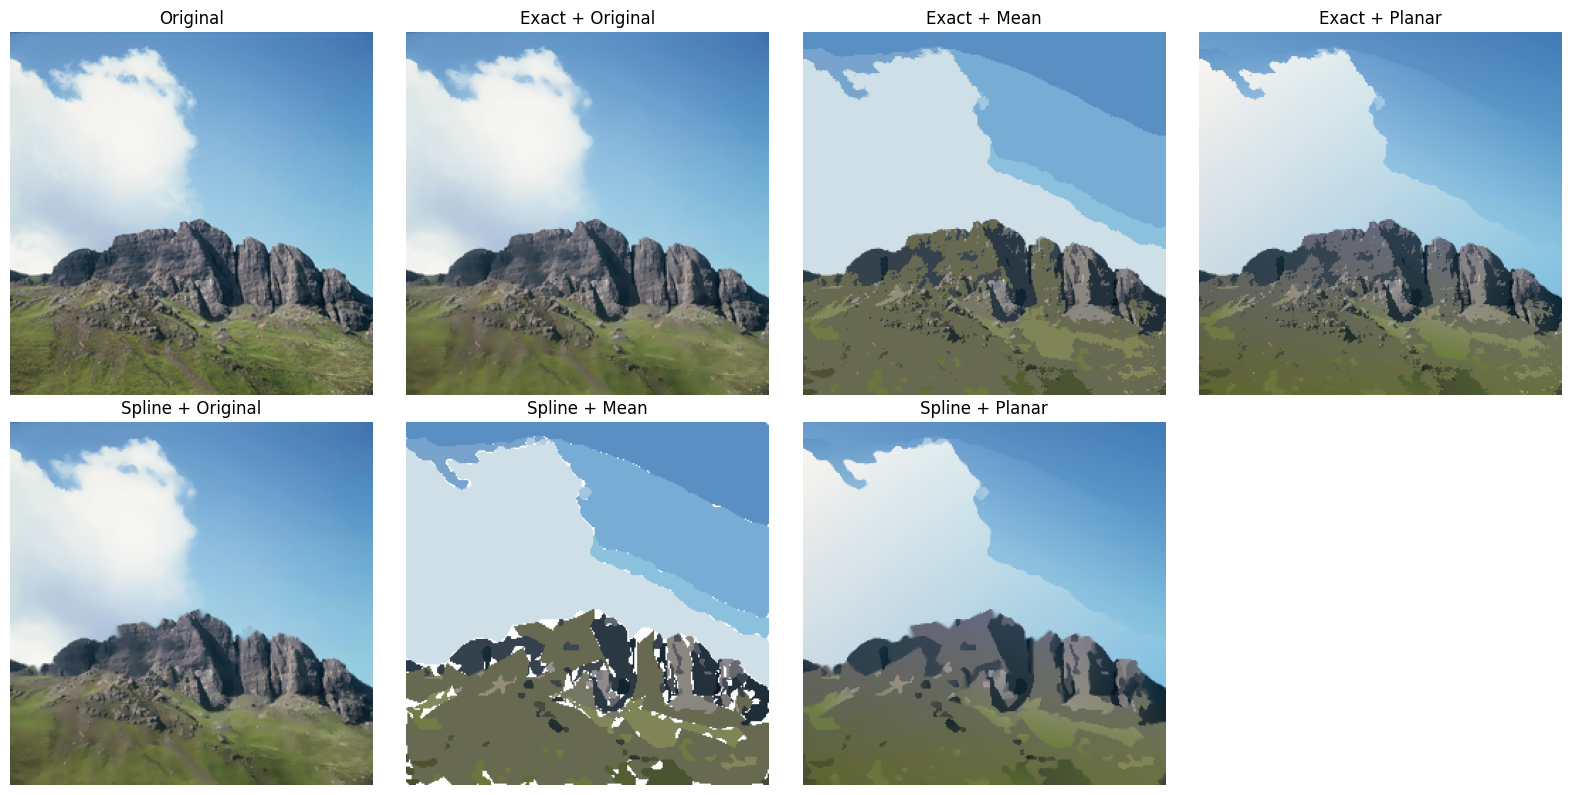

In [72]:
items = [
    ("Original", orig_rgb),
    ("Exact + Original", C_rgb),
    ("Exact + Mean", A_rgb),
    ("Exact + Planar", D_rgb),
    ("Spline + Original", F_rgb),
    ("Spline + Mean", B_rgb),
    ("Spline + Planar", E_rgb),
]

fig, ax = plt.subplots(2, 4, figsize=(16, 8))
ax = ax.ravel()

for i, (title, img) in enumerate(items):
    ax[i].imshow(img)
    ax[i].set_title(title, fontsize=12)
    ax[i].axis("off")

for j in range(len(items), len(ax)):
    ax[j].axis("off")

plt.tight_layout()
plt.show()
